check simply what \sigma_x projectors are when the slow quench stops at gf>0. Do they have any nontrivial features near DQPTs (detected through |<\psi_kz(t+\tau)|\psi_kz(\tau)|^2)?...Can we say something about the breakdown of the dilute gas picture near DQPTs, if yes then how do we quantify that (one possible way might be to be to check if there are many-body correlations or are they separable)?

In [1]:
import sys 

sys.path.append("../../src/")
from project_imports import *

import defect_projector as dp
import numerical_quenches as nq 
import general_projectors as gp

from numerical_quenches import groundstate
from general_projectors import P_generic
from defect_projector import Px_n_down as P_defect
import TFIM_operators_from_states as op

In [2]:
def free_evo_states(tau, gf, g0, L):

    tf = tau*(1-gf)

    # ramp from 0 to tf
    t_eval_quench = linspace(0, tf, 2)
    args = (tau, tf)

    states_quench = nq.states(L, t_eval_quench,
                              nq.g_linear_hold, args)

    # free evolution continues in absolute time
    t_eval_free = linspace(tf, tf + 2*np.pi, 100)

    states_free = nq.states(L, t_eval_free,
                            nq.g_linear_hold, args,
                            states_quench[-1])

    return states_free, t_eval_free

def P_defect_vector(n,sites,states):
    return array([P_defect(n,sites,s) for s in states])
def P_tilted_vector(n,nhat,states):
    return array([ P_generic(n,nhat,s) for s in states])

In [3]:
taus_free = [0.001, 1, 10, 30,50]
g0s = [30, 10, 5, 5,5]
gfs = [0.5, 0.25, 0.1, 0.05,0]
L = 600

free_states = {}
free_times = {}

for tau, g0 in zip(taus_free, g0s):
    for gf in gfs:

        states, t_eval = free_evo_states(tau, gf, g0, L)

        free_states[(tau, gf)] = states
        free_times[(tau, gf)] = t_eval

g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.0
g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.0
g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.0
g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.0
g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.0


In [63]:
def P_vector(n,states):
    return array([op.Px_n(n,s) for s in states])
def Pz_vector(n,states):
    return array([op.Pz_n(n,s) for s in states])

In [ ]:
ns= [2,4,6,8]
dat = {}

for (tau, gf), states_j in free_states.items():
    dat[(tau, gf)] = array([
        P_vector(n, states_j)
        for n in ns
    ])

print("Done!")

Done!


In [64]:
ns= [2,4,6,8]
dat2 = {}

for (tau, gf), states_j in free_states.items():
    dat2[(tau, gf)] = array([
        Pz_vector(n, states_j)
        for n in ns
    ])

print("Done!")

Done!


In [179]:
# tau = taus_free[0]   # choose which tau slice to view

# for i, n in enumerate(ns):

#     plt.figure()

#     for gf in gfs:
#         t = free_times[(tau, gf)]
#         y = dat[(tau, gf)][i]

#         plot(t, y, label=f"gf={gf}")

#     title(f"n = {n}, tau = {tau}")
#     xlabel("t")
#     ylabel("value")
#     legend()
#     show()

In [180]:
# tau = taus_free[0]   # same tau choice
# gf = gfs[0]          # choose a gf

# t = free_times[(tau, gf)]

# plt.figure()

# for i, n in enumerate(ns):
#     y = dat[(tau, gf)][i]
#     plot(t, y, label=f"n={n}")

# title(f"gf = {gf}, tau = {tau}")
# xlabel("t")
# ylabel("value")
# legend()
# show()

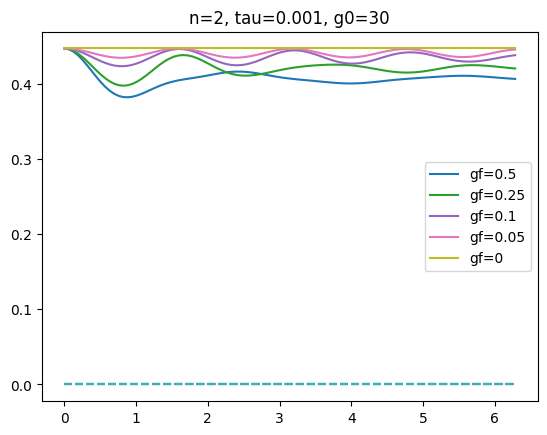

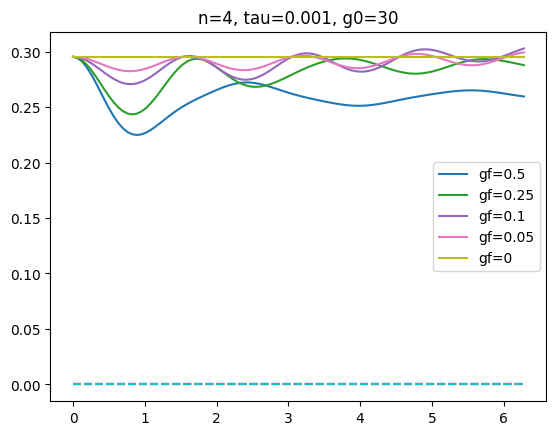

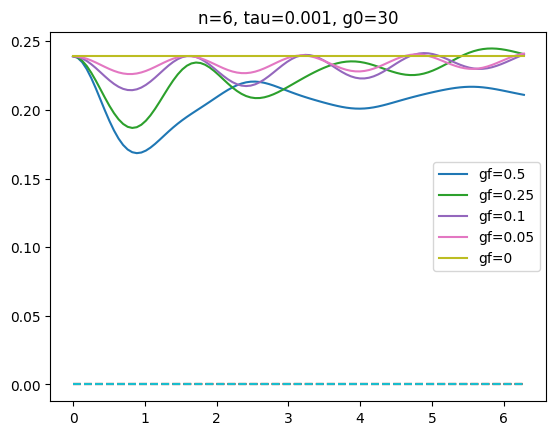

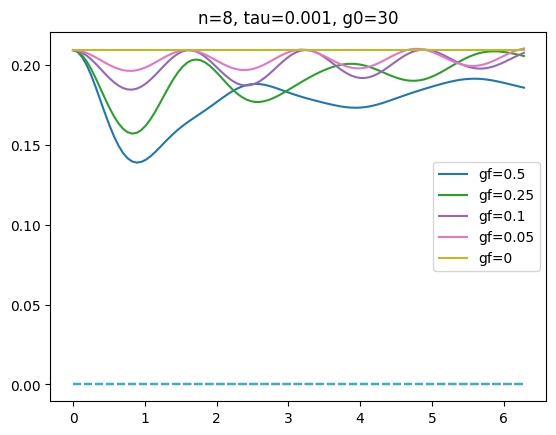

In [18]:
tau_index = 0
tau = taus_free[tau_index]
g0 = g0s[tau_index]

psi = groundstate(g0, L)

for i, n in enumerate(ns):


    for gf in gfs:

        states_j = free_states[(tau, gf)]
        t = free_times[(tau, gf)]
        t = t-t[0]

        y = dat[(tau, gf)][i]
        plot(t, -log(y)/n, label=f"gf={gf}")
        
        fs = groundstate(0,L)
        overlap = (nq.overlap(states_j, fs))
        plot(t, overlap, "--")

        #plot(t,-log(y)/ overlap, label=f"gf={gf}")

    title(f"n={n}, tau={tau}, g0={g0}")
    legend()
    show()

In [8]:
import TFIM_operators_from_states as op

from TFIM_operators_from_states import Px_n 

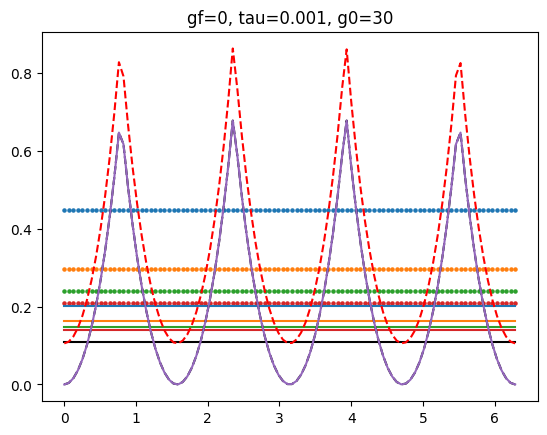

In [70]:
tau_index = 0
tau = taus_free[tau_index]
g0 = g0s[tau_index]
gf = gfs[-1]

psi = groundstate(g0, L)
psi_f = groundstate(0,L)

states_j = free_states[(tau, gf)]
t = free_times[(tau, gf)]
overlap = -log(nq.overlap(states_j, states_j[0]))/L
overlap2 = (nq.overlap(states_j, psi_f))
overlap3 = (nq.overlap(states_j, psi))


for i, n in enumerate(ns):
    y = dat[(tau, gf)][i]
    z = dat[(tau,gf)][i]
    delta = Px_n(n,psi_f)-y
    plot(t, -log(2*y)/(n-1), label=f"n={n}")
    scatter(t, -log(z)/(n), label=f"n={n}",s=5)

y = dat[(tau, gf)][0]
plot(t, overlap, "--k", label="overlap with tau state")
plot(t, -log(overlap2)/L, "k", label="overlap with gf state")
plot(t, -log(overlap3)/L, "--r", label="overlap with g0 state")

title(f"gf={gf}, tau={tau}, g0={g0}")
plot(t, -np.log(abs(nq.overlap(states_j, states_j[0])))/L)
#legend()
show()

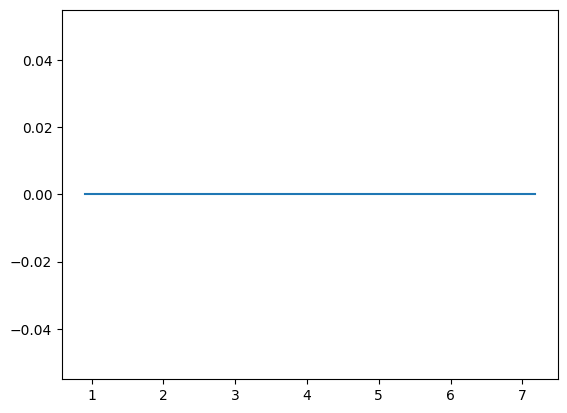

In [55]:
plot(t, np.gradient(np.unwrap(np.angle(nq.overlap(states_j, states_j[0]))), t))

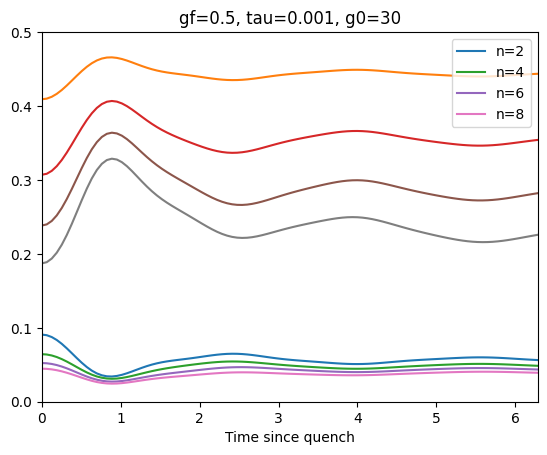

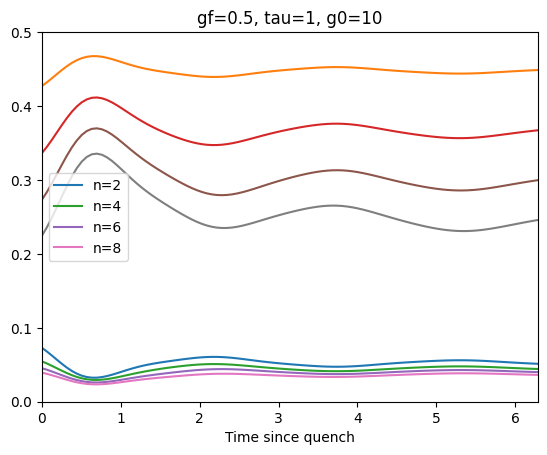

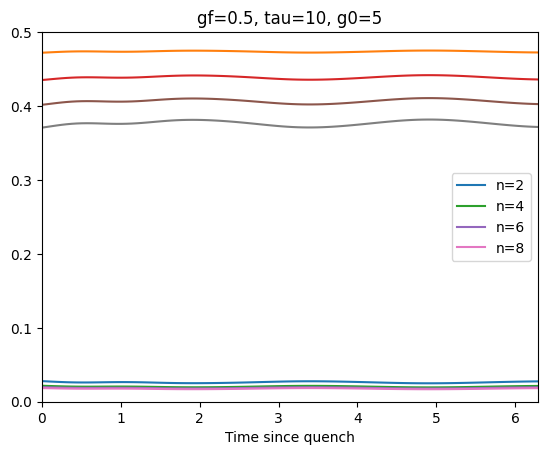

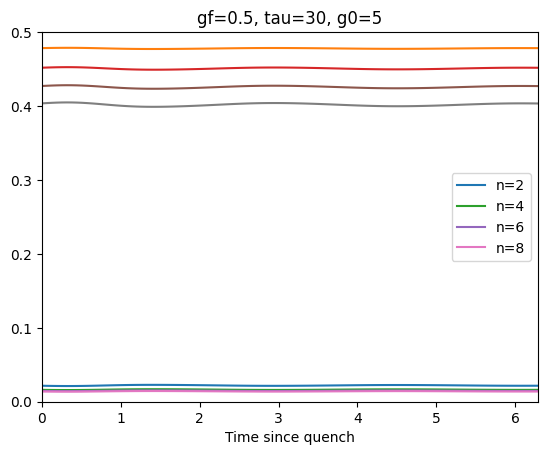

In [36]:
for tau_index in range(4):
    tau = taus_free[tau_index]
    g0 = g0s[tau_index]
    gf = gfs[0]

    psi = groundstate(g0, L)
    psi_f = groundstate(0,L)

    states_j = free_states[(tau, gf)]
    t = free_times[(tau, gf)]
    overlap = -log(nq.overlap(states_j, states_j[0]))/L
    overlap2 = (nq.overlap(states_j, psi_f))


    for i, n in enumerate(ns):
        y = dat[(tau, gf)][i]
        delta = Px_n(n,psi_f)-y
        t= t-t[0]
        plot(t, delta/(n-1), label=f"n={n}")
        plot(t,y)
    y = dat[(tau, gf)][0]
    #plot(t, overlap, "--k", label="overlap with tau state")
    #plot(t, (overlap2), "k", label="overlap with g0 state")

    title(f"gf={gf}, tau={tau}, g0={g0}")
    legend()
    ylim(0,.5)
    xlabel("Time since quench")
    xlim(t[0],t[-1])
    show()

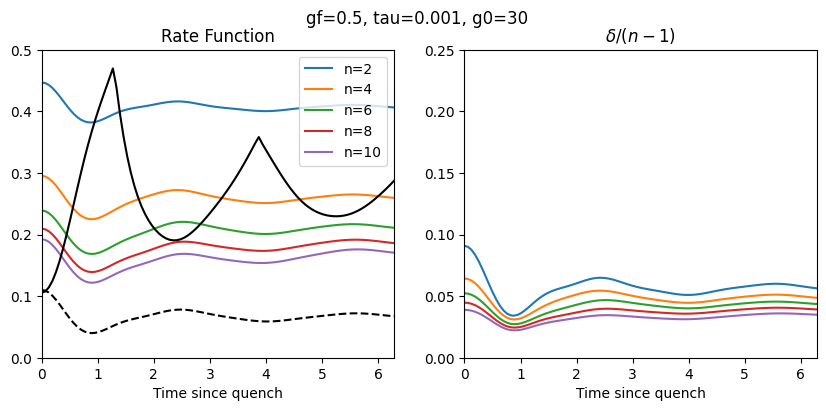

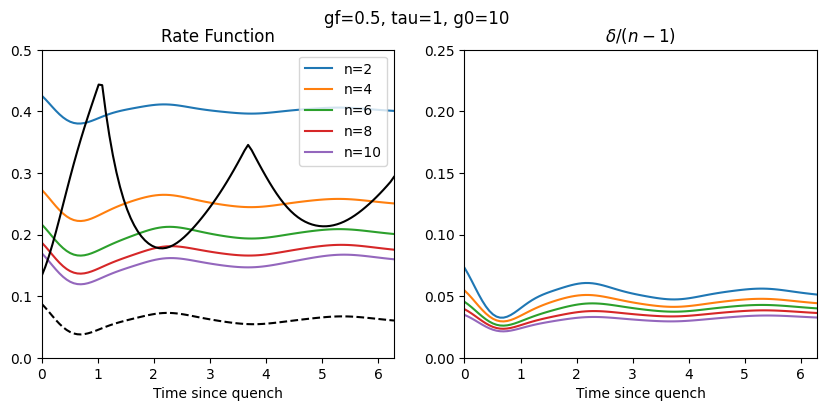

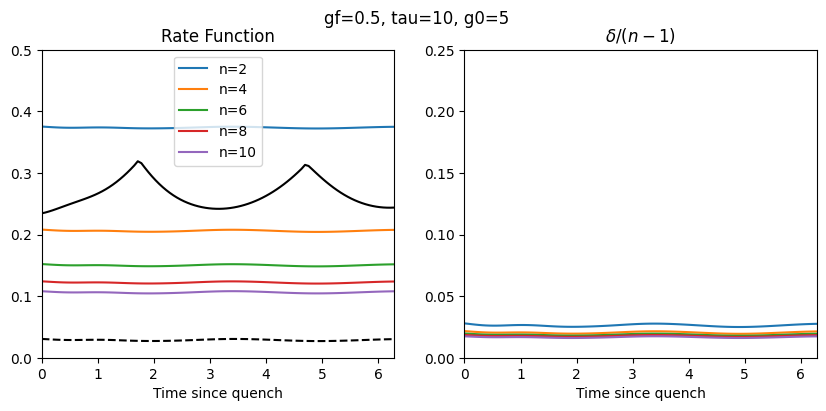

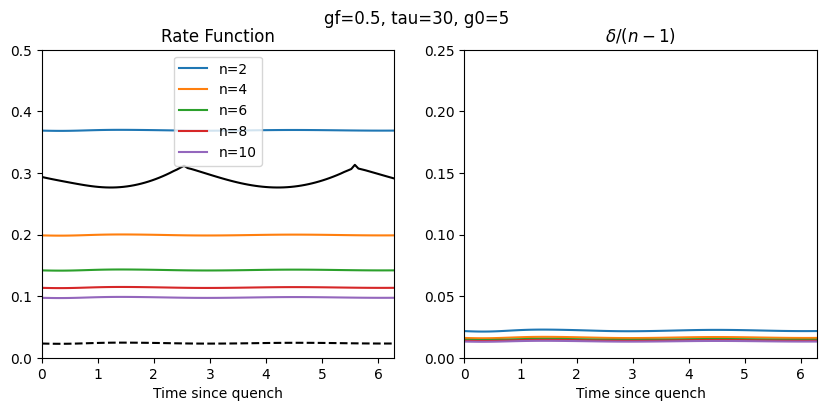

In [211]:
for tau_index in range(4):

    tau = taus_free[tau_index]
    g0 = g0s[tau_index]
    gf = gfs[0]

    psi = groundstate(g0, L)
    psi_f = groundstate(0, L)

    states_j = free_states[(tau, gf)]
    t = free_times[(tau, gf)]
    t = t - t[0]

    overlap = (nq.overlap(states_j, psi))
    overlap2 = nq.overlap(states_j, psi_f)

    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    for i, n in enumerate(ns):

        y = dat[(tau, gf)][i]
        delta = Px_n(n, psi_f) - y

        ax[0].plot(t, -log(y)/n, label=f"n={n}")
        ax[1].plot(t, delta/(n-1), label=f"n={n}")
    ax[0].plot(t,-log(overlap2)/L,"--k")
    ax[0].plot(t,-log(overlap)/L,"k")

    ax[0].set_title("Rate Function")
    ax[1].set_title(r"$\delta/(n-1)$")

    for a in ax:
        a.set_xlim(t[0], t[-1])
        a.set_ylim(0, .5)
        a.set_xlabel("Time since quench")
    ax[1].set_ylim(0,.25)
    ax[0].legend()

    fig.suptitle(f"gf={gf}, tau={tau}, g0={g0}")
    show()

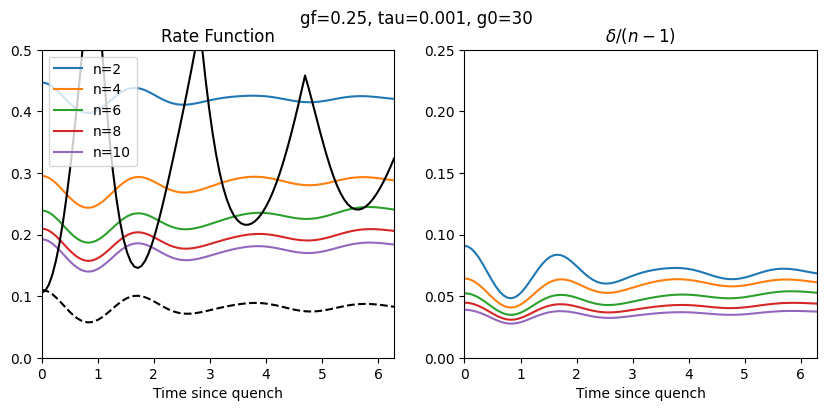

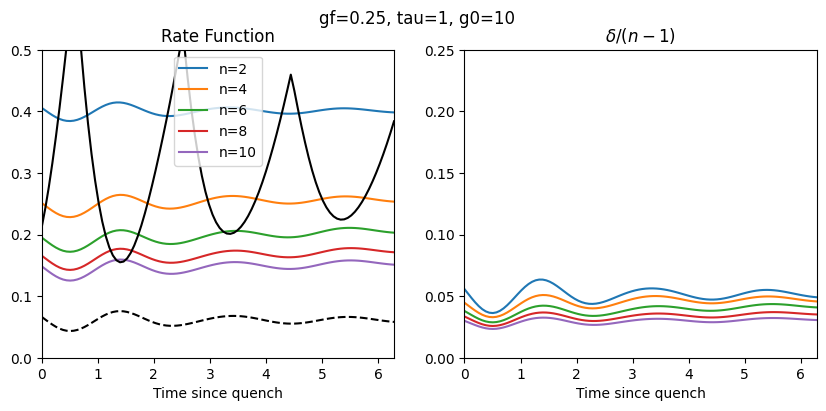

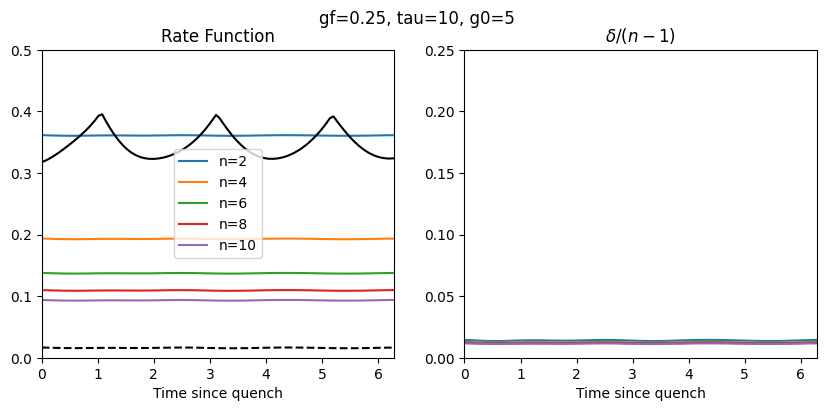

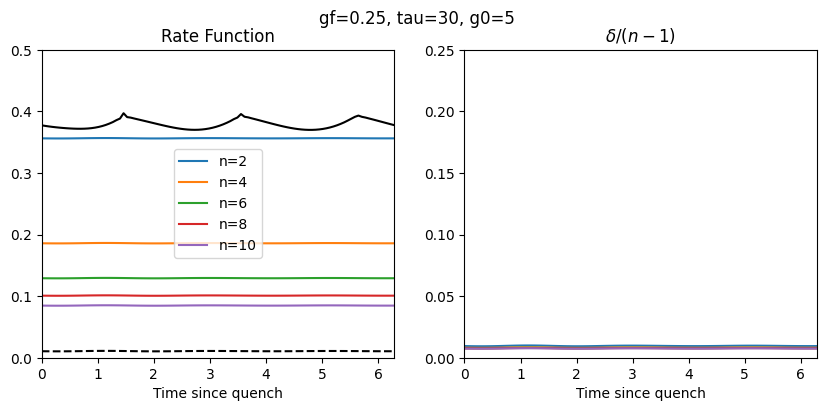

In [212]:
for tau_index in range(4):

    tau = taus_free[tau_index]
    g0 = g0s[tau_index]
    gf = gfs[1]

    psi = groundstate(g0, L)
    psi_f = groundstate(0, L)

    states_j = free_states[(tau, gf)]
    t = free_times[(tau, gf)]
    t = t - t[0]

    overlap = (nq.overlap(states_j, psi))
    overlap2 = nq.overlap(states_j, psi_f)

    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    for i, n in enumerate(ns):

        y = dat[(tau, gf)][i]
        delta = Px_n(n, psi_f) - y

        ax[0].plot(t, -log(y)/n, label=f"n={n}")
        ax[1].plot(t, delta/(n-1), label=f"n={n}")
    ax[0].plot(t,-log(overlap2)/L,"--k")
    ax[0].plot(t,-log(overlap)/L,"k")

    ax[0].set_title("Rate Function")
    ax[1].set_title(r"$\delta/(n-1)$")

    for a in ax:
        a.set_xlim(t[0], t[-1])
        a.set_ylim(0, .5)
        a.set_xlabel("Time since quench")
    ax[1].set_ylim(0,.25)
    ax[0].legend()

    fig.suptitle(f"gf={gf}, tau={tau}, g0={g0}")
    show()

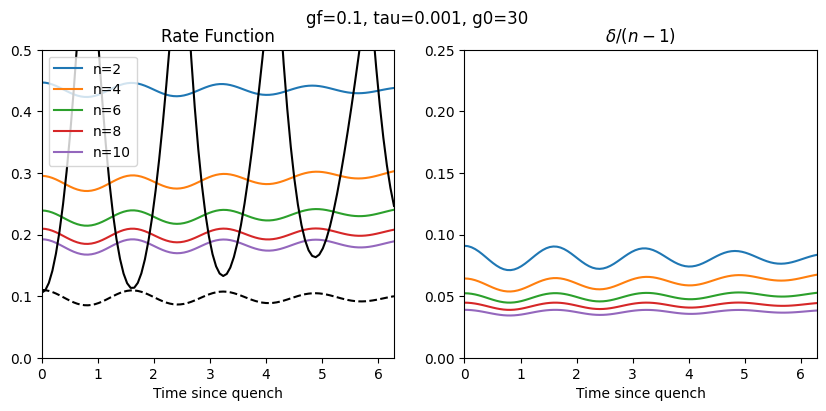

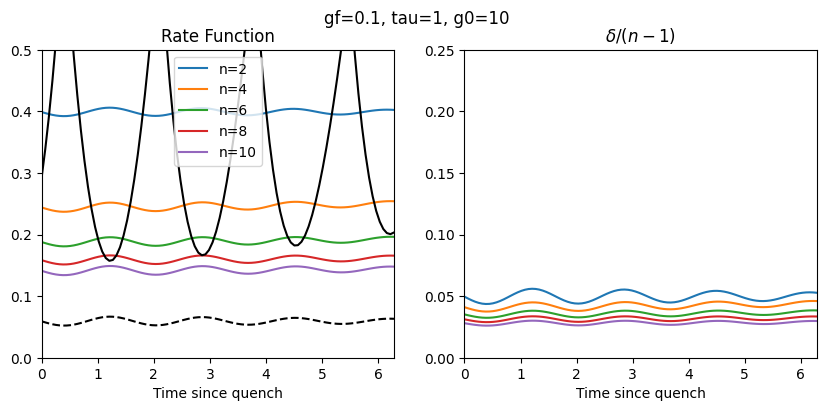

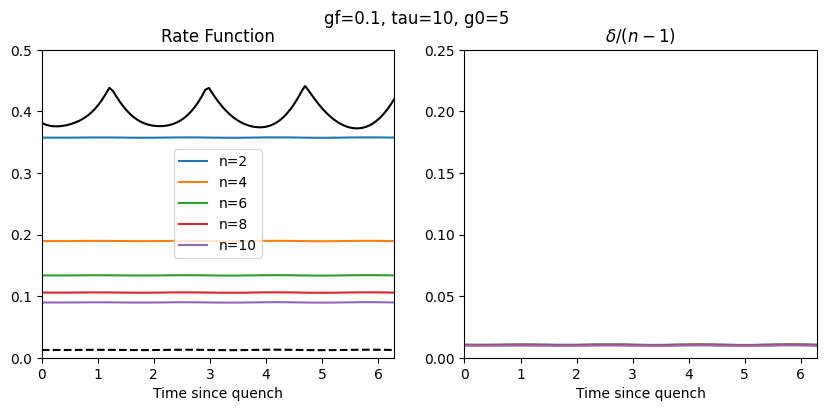

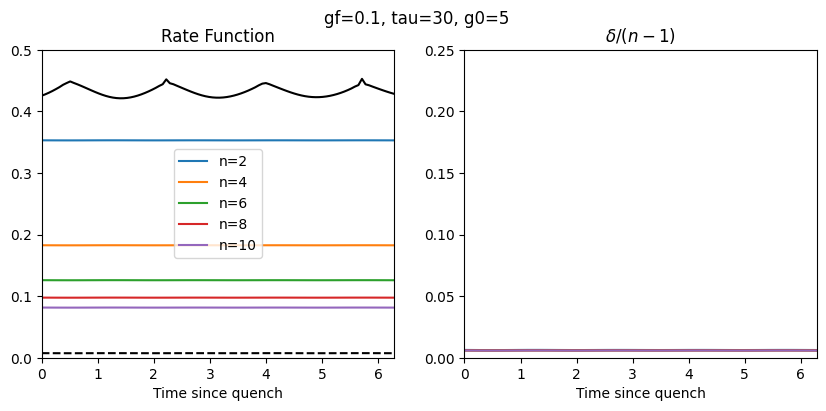

In [213]:
for tau_index in range(4):

    tau = taus_free[tau_index]
    g0 = g0s[tau_index]
    gf = gfs[2]

    psi = groundstate(g0, L)
    psi_f = groundstate(0, L)

    states_j = free_states[(tau, gf)]
    t = free_times[(tau, gf)]
    t = t - t[0]

    overlap = (nq.overlap(states_j, psi))
    overlap2 = nq.overlap(states_j, psi_f)

    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    for i, n in enumerate(ns):

        y = dat[(tau, gf)][i]
        delta = Px_n(n, psi_f) - y

        ax[0].plot(t, -log(y)/n, label=f"n={n}")
        ax[1].plot(t, delta/(n-1), label=f"n={n}")
    ax[0].plot(t,-log(overlap2)/L,"--k")
    ax[0].plot(t,-log(overlap)/L,"k")

    ax[0].set_title("Rate Function")
    ax[1].set_title(r"$\delta/(n-1)$")

    for a in ax:
        a.set_xlim(t[0], t[-1])
        a.set_ylim(0, .5)
        a.set_xlabel("Time since quench")
    ax[1].set_ylim(0,.25)
    ax[0].legend()

    fig.suptitle(f"gf={gf}, tau={tau}, g0={g0}")
    show()

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


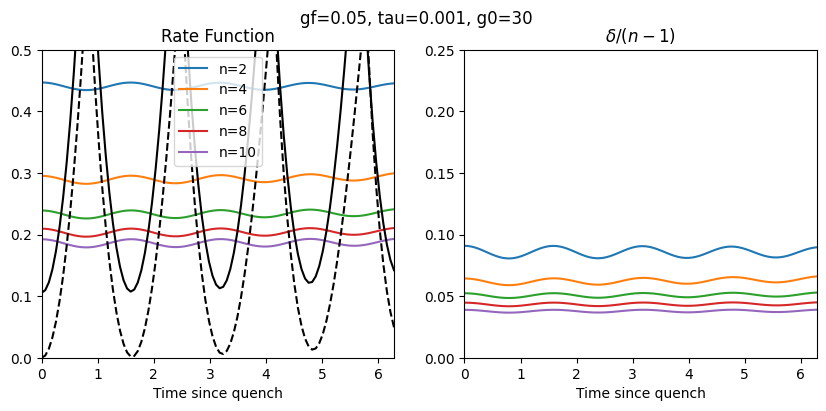

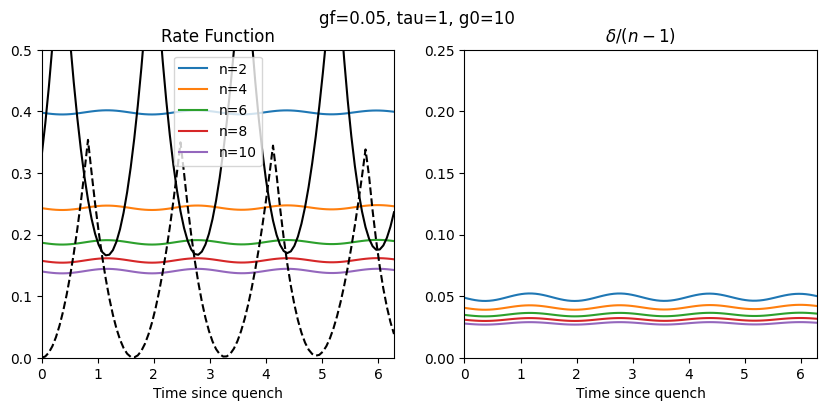

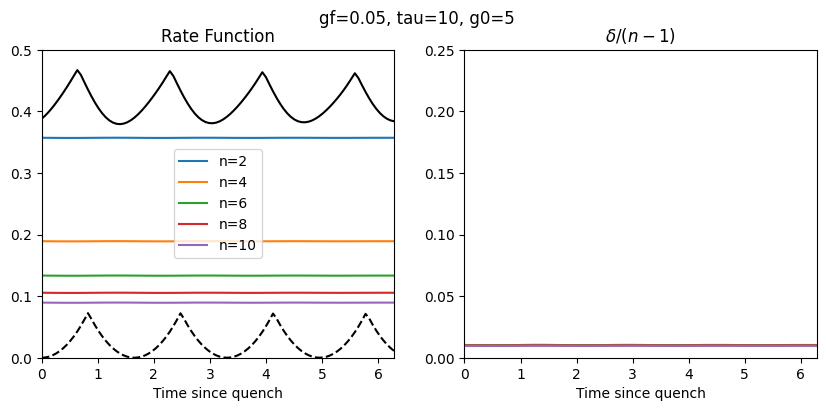

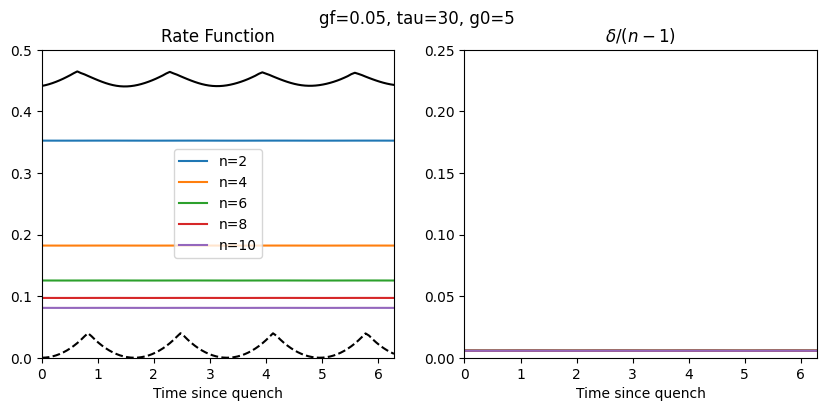

In [216]:
for tau_index in range(4):

    tau = taus_free[tau_index]
    g0 = g0s[tau_index]
    gf = gfs[3]

    psi = groundstate(g0, L)
    psi_f = groundstate(0, L)

    states_j = free_states[(tau, gf)]
    t = free_times[(tau, gf)]
    t = t - t[0]

    overlap = (nq.overlap(states_j, psi))
    overlap2 = nq.overlap(states_j, states_j[0])

    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    for i, n in enumerate(ns):

        y = dat[(tau, gf)][i]
        delta = Px_n(n, psi_f) - y

        ax[0].plot(t, -log(y)/n, label=f"n={n}")
        ax[1].plot(t, delta/(n-1), label=f"n={n}")
    ax[0].plot(t,-log(overlap2)/L,"--k")
    ax[0].plot(t,-log(overlap)/L,"k")

    ax[0].set_title("Rate Function")
    ax[1].set_title(r"$\delta/(n-1)$")

    for a in ax:
        a.set_xlim(t[0], t[-1])
        a.set_ylim(0, .5)
        a.set_xlabel("Time since quench")
    ax[1].set_ylim(0,.25)
    ax[0].legend()

    fig.suptitle(f"gf={gf}, tau={tau}, g0={g0}")
    show()

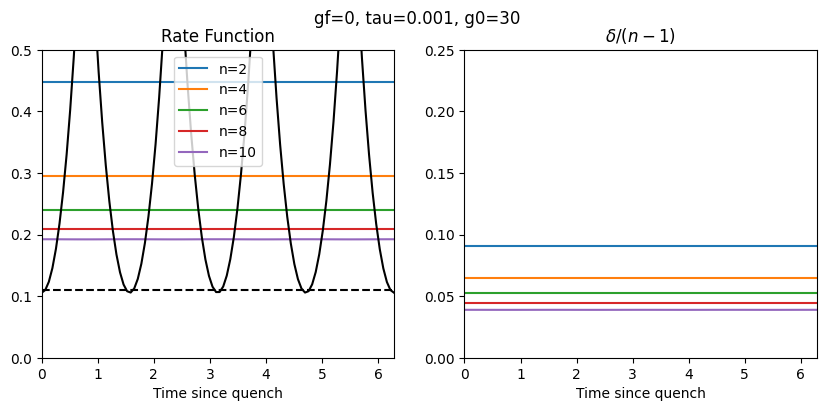

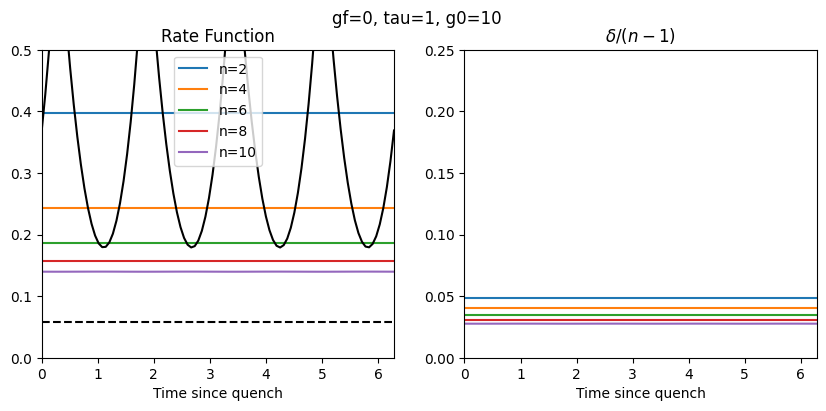

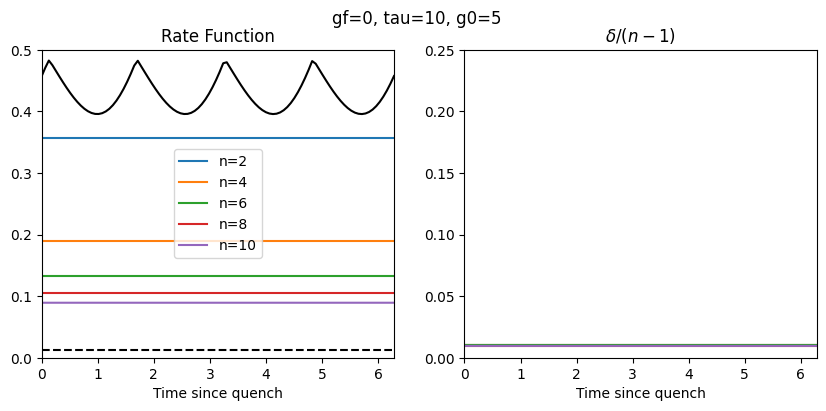

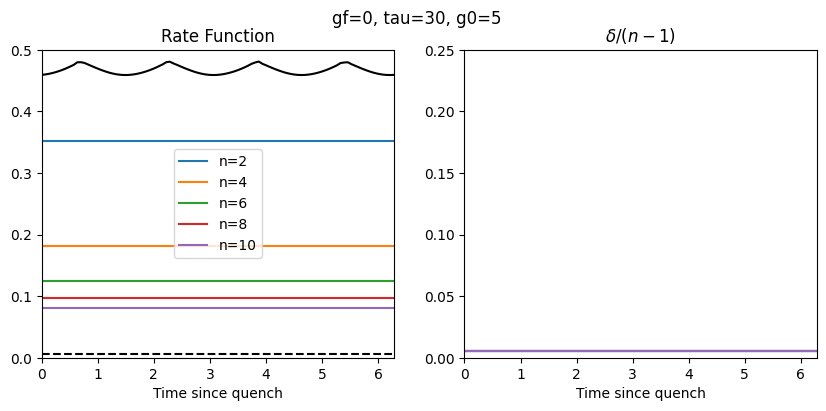

In [215]:
for tau_index in range(4):

    tau = taus_free[tau_index]
    g0 = g0s[tau_index]
    gf = gfs[4]

    psi = groundstate(g0, L)
    psi_f = groundstate(0, L)

    states_j = free_states[(tau, gf)]
    t = free_times[(tau, gf)]
    t = t - t[0]

    overlap = (nq.overlap(states_j, psi))
    overlap2 = nq.overlap(states_j, psi_f)

    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    for i, n in enumerate(ns):

        y = dat[(tau, gf)][i]
        delta = Px_n(n, psi_f) - y

        ax[0].plot(t, -log(y)/n, label=f"n={n}")
        ax[1].plot(t, delta/(n-1), label=f"n={n}")
    ax[0].plot(t,-log(overlap2)/L,"--k")
    ax[0].plot(t,-log(overlap)/L,"k")

    ax[0].set_title("Rate Function")
    ax[1].set_title(r"$\delta/(n-1)$")

    for a in ax:
        a.set_xlim(t[0], t[-1])
        a.set_ylim(0, .5)
        a.set_xlabel("Time since quench")
    ax[1].set_ylim(0,.25)
    ax[0].legend()

    fig.suptitle(f"gf={gf}, tau={tau}, g0={g0}")
    show()

# Ferromangetic 

In [ ]:
def g_ferro(t,args):
    gf, tau = args
    g = t/tau
    if g > t/tau:
        return gf 
    else:
        return g
    

In [ ]:
def free_evo_states(tau, gf, g0, L):

    tf = tau*(1-gf)

    # ramp from 0 to tf
    t_eval_quench = linspace(0, tf, 2)
    args = (tau, tf)

    states_quench = nq.states(L, t_eval_quench,
                              nq.g_ferromagquench, args)

    # free evolution continues in absolute time
    t_eval_free = linspace(tf, tf + 2*np.pi, 100)

    states_free = nq.states(L, t_eval_free,
                            nq.g_linear_hold, args,
                            states_quench[-1])

    return states_free, t_eval_free

def P_defect_vector(n,sites,states):
    return array([P_defect(n,sites,s) for s in states])
def P_tilted_vector(n,nhat,states):
    return array([ P_generic(n,nhat,s) for s in states])